# Segmentation client (Clustering)

L’objectif ici est de segmenter la clientèle selon des comportements d’achat et des caractéristiques socio-économiques similaires.

Cette partie regroupe plusieurs étapes :

- Préparation des données : sélection des variables pertinentes (issues du feature engineering).

- Standardisation des variables pour éviter les biais liés aux échelles différentes.

- Application d’un algorithme de clustering.

- Évaluation des clusters (inertie, silhouette score, etc.).

- Analyse et interprétation des groupes de clients pour comprendre leurs profils (par exemple : "gros dépensiers", "familles nombreuses", "acheteurs en ligne", etc.).

Cette segmentation permet d’identifier des groupes homogènes afin d’orienter les campagnes marketing et d’améliorer la stratégie commerciale.

,Identifiant,Année_naissance,Education,Situation_matrimoniale,Revenu,Enfant_charge,Ado_charge,Date_acquisition_client,Nombre_jours_depuis_dernier_achat,Montant_vin,...,Part_plaisir,Taux_depense_sur_revenu,Total_achats,Part_achats_en_ligne,Part_achats_catalogue,Taux_visite_achat_web,Nb_enfants_total,Age,Score_engagement_marketing,Taux_acceptation_campagne
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09,58,635.0,...,0.501546,0.027813,22,0.363636,0.454545,1.142857,0,57,0,0.0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03,38,11.0,...,0.666667,0.000583,4,0.250000,0.250000,0.200000,2,60,0,0.0
2,4141,1965,Graduation,Together,71613.0,0,0,1970-01-01,26,426.0,...,0.630155,0.010836,20,0.400000,0.100000,2.000000,0,49,0,0.0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02,26,11.0,...,0.358491,0.001989,6,0.333333,0.000000,0.333333,1,30,0,0.0
4,5324,1981,PhD,Married,58293.0,1,0,1970-01-01,94,173.0,...,0.509479,0.007239,14,0.357143,0.214286,1.000000,1,33,0,0.0
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520.0,...,0.804469,0.011454,20,0.300000,0.200000,1.000000,1,47,0,0.0
6,965,1971,Graduation,Divorced,55635.0,0,1,1970-01-01,34,235.0,...,0.527119,0.010605,17,0.411765,0.176471,1.166667,1,43,0,0.0
7,6177,1985,PhD,Married,33454.0,1,0,2013-08-05,32,76.0,...,0.591716,0.005052,8,0.500000,0.000000,0.500000,1,29,0,0.0


✅ 2233 lignes, 41 colonnes  |  écrit → data/processed/features_enriched.csv


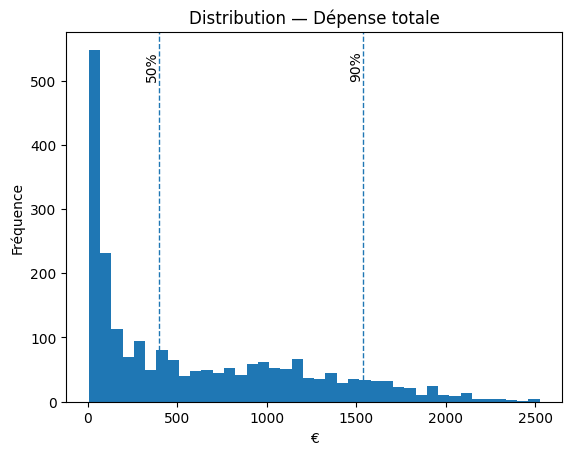

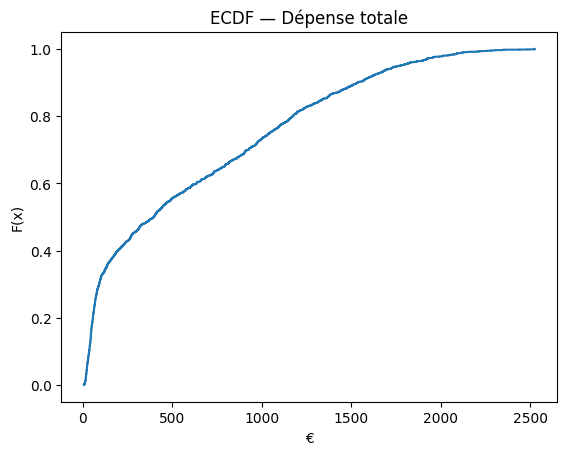

/var/folders/xl/rykcwm893qjgcmqclhb0nnpw0000gn/T/ipykernel_10862/3420705687.py:120: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


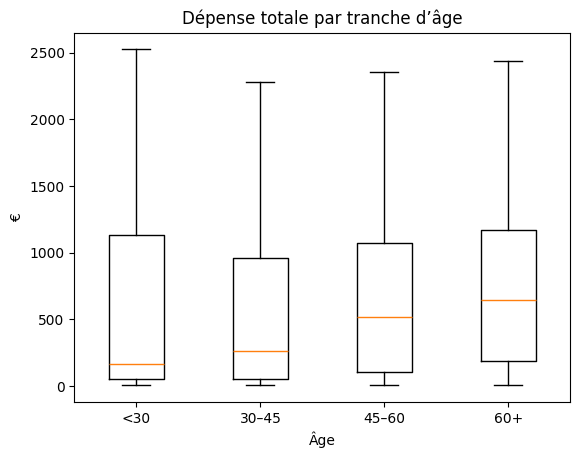

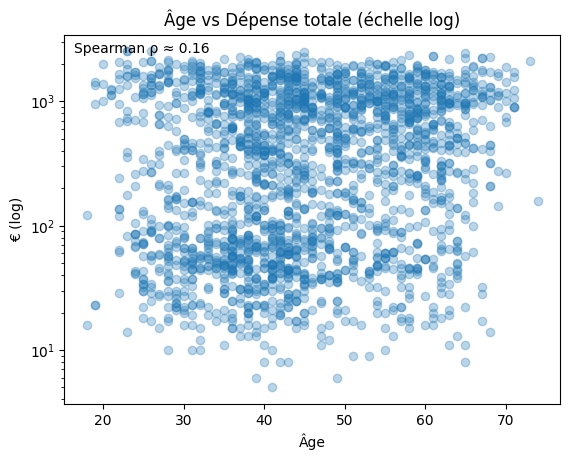

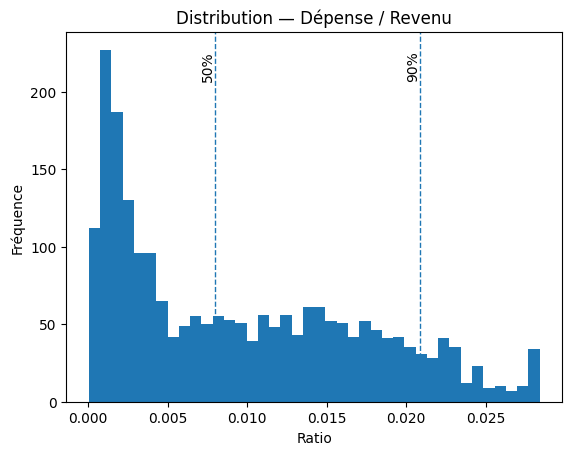

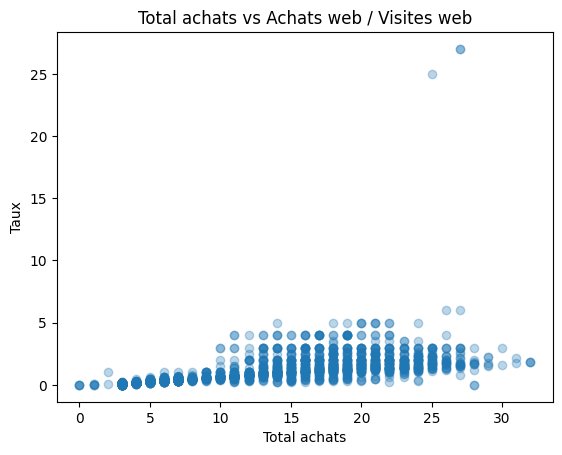

/var/folders/xl/rykcwm893qjgcmqclhb0nnpw0000gn/T/ipykernel_10862/3420705687.py:155: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m = df.groupby(q, dropna=False)["Part_achats_en_ligne"].mean()


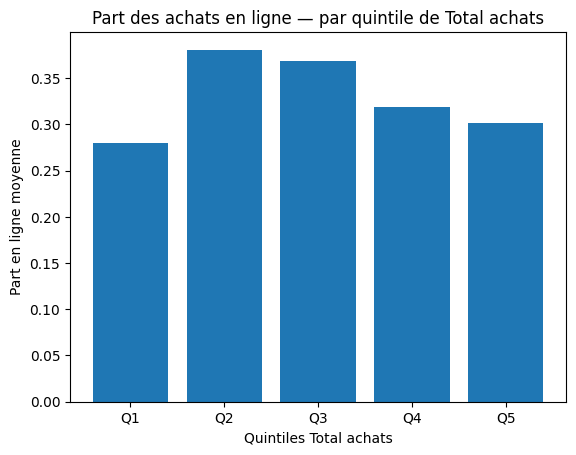

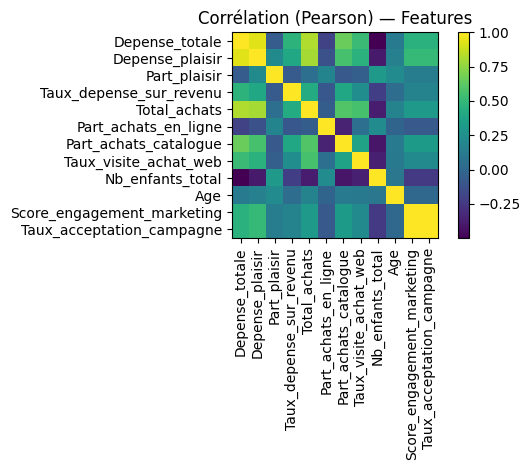

In [ ]:
# Config
INPUT_CSV  = "data/processed/camp_market_clean.csv"
OUTPUT_CSV = "data/processed/features_enriched.csv"
REF_YEAR   = 2014
READ_SEP   = "auto"
READ_ENC   = "utf-8"

# Imports 
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utils
def _read_csv(path: str, sep="auto", encoding="utf-8") -> pd.DataFrame:
    if sep == "auto":
        try:    return pd.read_csv(path, sep=None, engine="python", encoding=encoding)
        except UnicodeDecodeError: return pd.read_csv(path, sep=None, engine="python", encoding="latin-1")
    try:        return pd.read_csv(path, sep=sep, encoding=encoding)
    except UnicodeDecodeError: return pd.read_csv(path, sep=sep, encoding="latin-1")

def _ensure_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            s = df[c].astype(str).str.replace(",", ".", regex=False)
            df[c] = pd.to_numeric(s.str.replace(r"[^0-9\.\-eE+]", "", regex=True), errors="coerce")
    return df

def _zeros(df: pd.DataFrame) -> pd.Series: return pd.Series(0.0, index=df.index)
def _nans(df: pd.DataFrame) -> pd.Series:  return pd.Series(np.nan, index=df.index)
def _vdiv(a: pd.Series, b: pd.Series) -> pd.Series:
    b = pd.to_numeric(b, errors="coerce").replace(0, np.nan)
    a = pd.to_numeric(a, errors="coerce")
    return a / b

# Schémas FR/EN
COLMAPS = [
    {"vin":"MntWines","fruits":"MntFruits","viande":"MntMeatProducts","poisson":"MntFishProducts",
     "sucreries":"MntSweetProducts","luxe":"MntGoldProds","achats_web":"NumWebPurchases",
     "achats_catalogue":"NumCatalogPurchases","achats_magasin":"NumStorePurchases",
     "visites_web":"NumWebVisitsMonth","enfant":"Kidhome","ado":"Teenhome",
     "annee_naissance":"Year_Birth","revenu":"Income",
     "cmp1":"AcceptedCmp1","cmp2":"AcceptedCmp2","cmp3":"AcceptedCmp3","cmp4":"AcceptedCmp4","cmp5":"AcceptedCmp5"},
    {"vin":"Montant_vin","fruits":"Montant_fruits","viande":"Montant_viande","poisson":"Montant_poisson",
     "sucreries":"Montant_sucreries","luxe":"Montant_luxe","achats_web":"Nb_achats_en_ligne",
     "achats_catalogue":"Achats_catalogue","achats_magasin":"Achats_magasin",
     "visites_web":"Nb_visites_web_mois","enfant":"Enfant_charge","ado":"Ado_charge",
     "annee_naissance":"Année_naissance","revenu":"Revenu",
     "cmp1":"Accepte_Campagne_1","cmp2":"Accepte_Campagne_2","cmp3":"Accepte_Campagne_3","cmp4":"Accepte_Campagne_4","cmp5":"Accepte_Campagne_5"},
]
def _pick_map(df: pd.DataFrame) -> dict:
    return max(COLMAPS, key=lambda m: sum(v in df.columns for v in m.values()))

# Features
def engineer_features(df: pd.DataFrame, ref_year: int) -> pd.DataFrame:
    m = _pick_map(df)
    def col(k: str, zero=True) -> pd.Series:
        c = m[k]
        if c in df.columns: return df[c]
        warnings.warn(f"[WARN] Colonne absente: {c} → valeurs par défaut {'0' if zero else 'NaN'}.")
        return _zeros(df) if zero else _nans(df)

    _ensure_numeric(df, [v for m in COLMAPS for v in m.values() if v in df.columns])

    vin, fruits, viande, poisson = col("vin"), col("fruits"), col("viande"), col("poisson")
    sucre, luxe = col("sucreries"), col("luxe")
    a_web, a_cat, a_mag = col("achats_web"), col("achats_catalogue"), col("achats_magasin")
    v_web, yb, rev = col("visites_web"), col("annee_naissance"), col("revenu")
    cmp1, cmp2, cmp3, cmp4, cmp5 = col("cmp1"), col("cmp2"), col("cmp3"), col("cmp4"), col("cmp5")

    out = df.copy()
    out["Depense_totale"]            = vin + fruits + viande + poisson + sucre + luxe
    out["Depense_plaisir"]           = vin + sucre + luxe
    out["Part_plaisir"]              = _vdiv(out["Depense_plaisir"], out["Depense_totale"])
    out["Taux_depense_sur_revenu"]   = _vdiv(out["Depense_totale"], rev)
    out["Total_achats"]              = a_web + a_cat + a_mag
    out["Part_achats_en_ligne"]      = _vdiv(a_web, out["Total_achats"])
    out["Part_achats_catalogue"]     = _vdiv(a_cat, out["Total_achats"])
    out["Taux_visite_achat_web"]     = _vdiv(a_web, v_web)
    out["Nb_enfants_total"]          = col("enfant") + col("ado")
    out["Age"]                       = ref_year - yb
    out["Score_engagement_marketing"]= cmp1 + cmp2 + cmp3 + cmp4 + cmp5
    out["Taux_acceptation_campagne"] = out["Score_engagement_marketing"] / 5.0
    return out

# Graphs
def _perc_lines(ax, s: pd.Series, qs=(0.5, 0.9)):
    for q in qs:
        x = np.nanquantile(s, q)
        ax.axvline(x, linestyle="--", linewidth=1)
        ax.text(x, ax.get_ylim()[1]*0.95, f"{int(q*100)}%", rotation=90, va="top", ha="right")

def better_graphs(df: pd.DataFrame):
    # 1) Dépense totale — hist + médiane/90%
    fig, ax = plt.subplots()
    s = df["Depense_totale"].dropna()
    ax.hist(s, bins=40)
    ax.set_title("Distribution — Dépense totale")
    ax.set_xlabel("€"); ax.set_ylabel("Fréquence")
    _perc_lines(ax, s)
    plt.show()

    # 2) Dépense totale — ECDF (lecture des queues)
    fig, ax = plt.subplots()
    x = np.sort(s.values); y = np.linspace(0, 1, len(x), endpoint=True)
    ax.step(x, y, where="post")
    ax.set_title("ECDF — Dépense totale"); ax.set_xlabel("€"); ax.set_ylabel("F(x)")
    plt.show()

    # 3) Boxplots Dépense par tranches d’âge
    fig, ax = plt.subplots()
    bins = [0, 30, 45, 60, 120]
    labels = ["<30","30–45","45–60","60+"]
    age_band = pd.cut(df["Age"], bins=bins, labels=labels, include_lowest=True)
    data = [df.loc[age_band==lab, "Depense_totale"].dropna() for lab in labels]
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title("Dépense totale par tranche d’âge"); ax.set_xlabel("Âge"); ax.set_ylabel("€")
    plt.show()

    # 4) Scatter Âge vs Dépense (log y) + corr Spearman
    fig, ax = plt.subplots()
    x = df["Age"]; y = df["Depense_totale"]
    ax.scatter(x, y, alpha=0.3)
    ax.set_yscale("log")
    ax.set_title("Âge vs Dépense totale (échelle log)")
    ax.set_xlabel("Âge"); ax.set_ylabel("€ (log)")
    try:
        rho = pd.Series(x).corr(pd.Series(y), method="spearman")
        ax.annotate(f"Spearman ρ ≈ {rho:.2f}", xy=(0.02, 0.95), xycoords="axes fraction")
    except Exception:
        pass
    plt.show()

    # 5) Ratio dépense/revenu
    fig, ax = plt.subplots()
    r = df["Taux_depense_sur_revenu"].clip(upper=np.nanquantile(df["Taux_depense_sur_revenu"], 0.99)).dropna()
    ax.hist(r, bins=40)
    ax.set_title("Distribution — Dépense / Revenu"); ax.set_xlabel("Ratio"); ax.set_ylabel("Fréquence")
    _perc_lines(ax, r)
    plt.show()

    # 6) Taux visite→achat web vs Total achats
    fig, ax = plt.subplots()
    ax.scatter(df["Total_achats"], df["Taux_visite_achat_web"], alpha=0.3)
    ax.set_title("Total achats vs Achats web / Visites web"); ax.set_xlabel("Total achats"); ax.set_ylabel("Taux")
    plt.show()

    # 7) Part en ligne moyenne par quintile de Total achats
    fig, ax = plt.subplots()
    q = pd.qcut(df["Total_achats"].rank(method="first"), q=5, labels=["Q1","Q2","Q3","Q4","Q5"])
    m = df.groupby(q, dropna=False)["Part_achats_en_ligne"].mean()
    ax.bar(m.index.astype(str), m.values)
    ax.set_title("Part des achats en ligne — par quintile de Total achats")
    ax.set_xlabel("Quintiles Total achats"); ax.set_ylabel("Part en ligne moyenne")
    plt.show()

    # 8) Heatmap corrélations (features clés)
    cols = ["Depense_totale","Depense_plaisir","Part_plaisir","Taux_depense_sur_revenu",
            "Total_achats","Part_achats_en_ligne","Part_achats_catalogue","Taux_visite_achat_web",
            "Nb_enfants_total","Age","Score_engagement_marketing","Taux_acceptation_campagne"]
    corr = df[cols].corr(method="pearson", min_periods=1)
    fig, ax = plt.subplots()
    im = ax.imshow(corr, interpolation="nearest")
    fig.colorbar(im, ax=ax)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90)
    ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
    ax.set_title("Corrélation (Pearson) — Features")
    fig.tight_layout()
    plt.show()

# Pipeline
df_in  = _read_csv(INPUT_CSV, sep=READ_SEP, encoding=READ_ENC)
df_out = engineer_features(df_in, ref_year=REF_YEAR)
df_out.to_csv(OUTPUT_CSV, index=False)

display(df_out.head(8))
print(f"✅ {df_out.shape[0]} lignes, {df_out.shape[1]} colonnes  |  écrit → {OUTPUT_CSV}")

better_graphs(df_out)
